Loading arrays for chip: M1098029461CE_r2850_c450


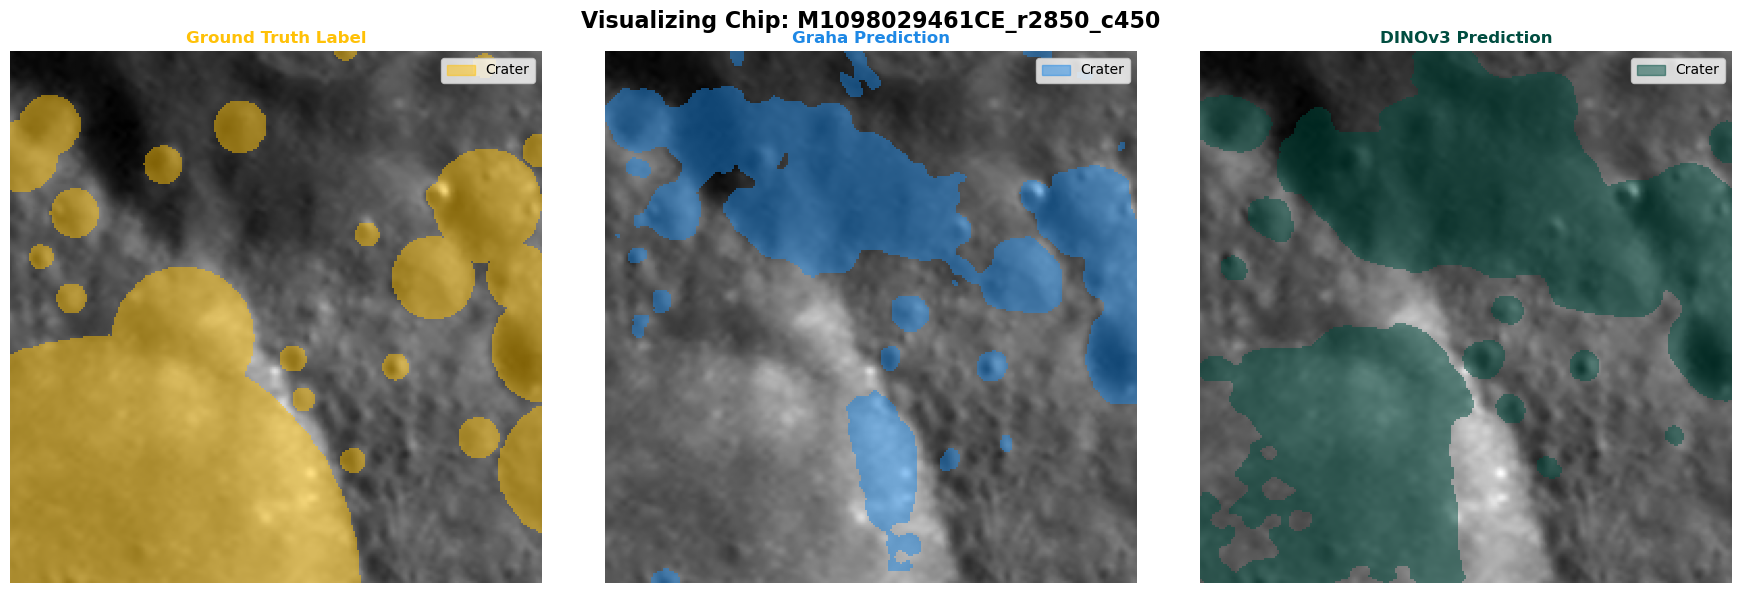

=== Graha Metrics for M1098029461CE_r2850_c450 ===
--- metrics.txt ---
model: Graha
checkpoint: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/toy_sem_seg_comparison/date_2026_07_17-time_15_11_31/checkpoints/full_model/last.ckpt
sample_key: M1098029461CE_r2850_c450
pixel_accuracy: 0.55421448
foreground_precision: 0.48906152
foreground_recall: 0.29696171
foreground_f1: 0.36953753
iou: 0.22664584
predicted_foreground_fraction: 0.26713562
ground_truth_foreground_fraction: 0.43994141

--- metrics.npy ---
(0.554214477538978, 0.48906151824956356, 0.2969617092118837, 0.36953753387290306, 0.22664584270846638, 0.26713562011714675, 0.4399414062499329)


=== DINOv3 Metrics for M1098029461CE_r2850_c450 ===
--- metrics.txt ---
model: Toy
checkpoint: /panfs/ccds02/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/toy_sem_seg_comparison/date_2026_07_17-time_15_11_31/checkpoints/toy_model/last.ckpt
sample_key: M1098029461CE

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Set base directories
BASE_DIR = "/explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/sem_ckpt_sweep_date_2026_07_20-time_09_28_28"
GRAHA_DIR = os.path.join(BASE_DIR, "graha_model", "last")
DINO_DIR = os.path.join(BASE_DIR, "toy_model", "last") 

# Get list of patches/chips and grab the first one
patch_dirs = [d for d in os.listdir(GRAHA_DIR) if os.path.isdir(os.path.join(GRAHA_DIR, d))]
sample_chip = patch_dirs[0]

print(f"Loading arrays for chip: {sample_chip}")

# Construct paths for the sample chip
input_path = os.path.join(GRAHA_DIR, sample_chip, f"{sample_chip}_input.npy")
label_path = os.path.join(GRAHA_DIR, sample_chip, f"{sample_chip}_label.npy")
graha_pred_path = os.path.join(GRAHA_DIR, sample_chip, f"{sample_chip}_pred.npy")
dino_pred_path = os.path.join(DINO_DIR, sample_chip, f"{sample_chip}_pred.npy")

# Load arrays
input_img = np.load(input_path)
label_img = np.load(label_path)
graha_pred = np.load(graha_pred_path)
dino_pred = np.load(dino_pred_path)

# Ensure 2D shapes for visualization (taking first band of input)
img_to_plot = input_img[0]
label_mask = label_img[0] if label_img.ndim == 3 else label_img
graha_mask = graha_pred[0] if graha_pred.ndim == 3 else graha_pred
dino_mask = dino_pred[0] if dino_pred.ndim == 3 else dino_pred

# --- Helper Function for Colored Overlays ---
def create_overlay(mask, hex_color, alpha=0.5):
    """Converts a binary mask to an RGBA image with specified color and transparency."""
    rgb = mcolors.to_rgb(hex_color)
    overlay = np.zeros((*mask.shape, 4)) # Create empty RGBA array
    overlay[..., :3] = rgb               # Set color channels
    overlay[..., 3] = mask * alpha       # Set alpha channel (0 where mask is 0)
    return overlay

# Standardized Colors
COLOR_GT = "#FFC107"
COLOR_GRAHA = "#1E88E5"
COLOR_DINO = "#004D40"

# --- VISUALIZE OVERLAYS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Add the chip name as the main figure title
fig.suptitle(f"Visualizing Chip: {sample_chip}", fontsize=16, fontweight='bold')

# 1. Ground Truth Overlay
axes[0].imshow(img_to_plot, cmap='gray')
axes[0].imshow(create_overlay(label_mask, COLOR_GT, alpha=0.5), interpolation='none')
axes[0].set_title("Ground Truth Label", color=COLOR_GT, fontweight='bold')
axes[0].axis('off')
# Add legend
gt_patch = mpatches.Patch(color=COLOR_GT, alpha=0.5, label='Crater')
axes[0].legend(handles=[gt_patch], loc='upper right')

# 2. Graha Overlay
axes[1].imshow(img_to_plot, cmap='gray')
axes[1].imshow(create_overlay(graha_mask, COLOR_GRAHA, alpha=0.5), interpolation='none')
axes[1].set_title("Graha Prediction", color=COLOR_GRAHA, fontweight='bold')
axes[1].axis('off')
# Add legend
graha_patch = mpatches.Patch(color=COLOR_GRAHA, alpha=0.5, label='Crater')
axes[1].legend(handles=[graha_patch], loc='upper right')

# 3. DINOv3 Overlay
axes[2].imshow(img_to_plot, cmap='gray')
axes[2].imshow(create_overlay(dino_mask, COLOR_DINO, alpha=0.5), interpolation='none')
axes[2].set_title("DINOv3 Prediction", color=COLOR_DINO, fontweight='bold')
axes[2].axis('off')
# Add legend
dino_patch = mpatches.Patch(color=COLOR_DINO, alpha=0.5, label='Crater')
axes[2].legend(handles=[dino_patch], loc='upper right')

plt.tight_layout()
plt.show()

import os
import numpy as np

# Use the paths we already set up in Cell 1
chip_dir_graha = os.path.join(GRAHA_DIR, sample_chip)
chip_dir_dino = os.path.join(DINO_DIR, sample_chip)

def inspect_metrics(model_name, chip_dir):
    print(f"=== {model_name} Metrics for {sample_chip} ===")
    
    txt_path = os.path.join(chip_dir, "metrics.txt")
    npy_path = os.path.join(chip_dir, "metrics.npy")
    
    # 1. Read the text file
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as f:
            print("--- metrics.txt ---")
            print(f.read().strip())
    else:
        print("metrics.txt not found.")
        
    print()
    
    # 2. Read the numpy file
    if os.path.exists(npy_path):
        print("--- metrics.npy ---")
        try:
            npy_data = np.load(npy_path, allow_pickle=True)
            # If it's saved as a dictionary inside a 0-D array, extract it using .item()
            if npy_data.ndim == 0:
                print(npy_data.item())
            else:
                print(npy_data)
        except Exception as e:
            print(f"Could not read .npy file clearly: {e}")
    else:
        print("metrics.npy not found.")
    
    print("\n" + "="*50 + "\n")

# Run the inspection
inspect_metrics("Graha", chip_dir_graha)
inspect_metrics("DINOv3", chip_dir_dino)

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, jaccard_score

metrics_data = []
all_labels = []
all_graha_preds = []
all_dino_preds = []

print(f"Processing {len(patch_dirs)} chips...")

for chip in patch_dirs:
    label_path = os.path.join(GRAHA_DIR, chip, f"{chip}_label.npy")
    graha_pred_path = os.path.join(GRAHA_DIR, chip, f"{chip}_pred.npy")
    dino_pred_path = os.path.join(DINO_DIR, chip, f"{chip}_pred.npy")
    
    if os.path.exists(label_path) and os.path.exists(graha_pred_path) and os.path.exists(dino_pred_path):
        
        lbl = np.load(label_path).flatten()
        g_pred = np.load(graha_pred_path).flatten()
        d_pred = np.load(dino_pred_path).flatten()
        
        all_labels.extend(lbl)
        all_graha_preds.extend(g_pred)
        all_dino_preds.extend(d_pred)
        
        # Calculate Graha metrics (using binary average)
        metrics_data.append({
            "Model": "Graha",
            "Chip": chip,
            "Accuracy": accuracy_score(lbl, g_pred),
            "Precision": precision_score(lbl, g_pred, average='binary', zero_division=0),
            "Recall": recall_score(lbl, g_pred, average='binary', zero_division=0),
            "IoU": jaccard_score(lbl, g_pred, average='binary', zero_division=0)
        })
        
        # Calculate DINOv3 metrics (using binary average)
        metrics_data.append({
            "Model": "DINOv3",
            "Chip": chip,
            "Accuracy": accuracy_score(lbl, d_pred),
            "Precision": precision_score(lbl, d_pred, average='binary', zero_division=0),
            "Recall": recall_score(lbl, d_pred, average='binary', zero_division=0),
            "IoU": jaccard_score(lbl, d_pred, average='binary', zero_division=0)
        })

df_metrics = pd.DataFrame(metrics_data)
print("Processing complete!")

Processing 100 chips...
Processing complete!


OVERALL GLOBAL METRICS (All Pixels)
Graha  -> Accuracy (TP+FN): 0.8441 | Precision (TP/(TP+FP)): 0.6829 | Recall (TP/(TP+FN)): 0.4615 | IoU: 0.3801
DINOv3 -> Accuracy (TP+FN): 0.8948 | Precision (TP/(TP+FP)): 0.7929 | Recall (TP/(TP+FN)): 0.6659 | IoU: 0.5673


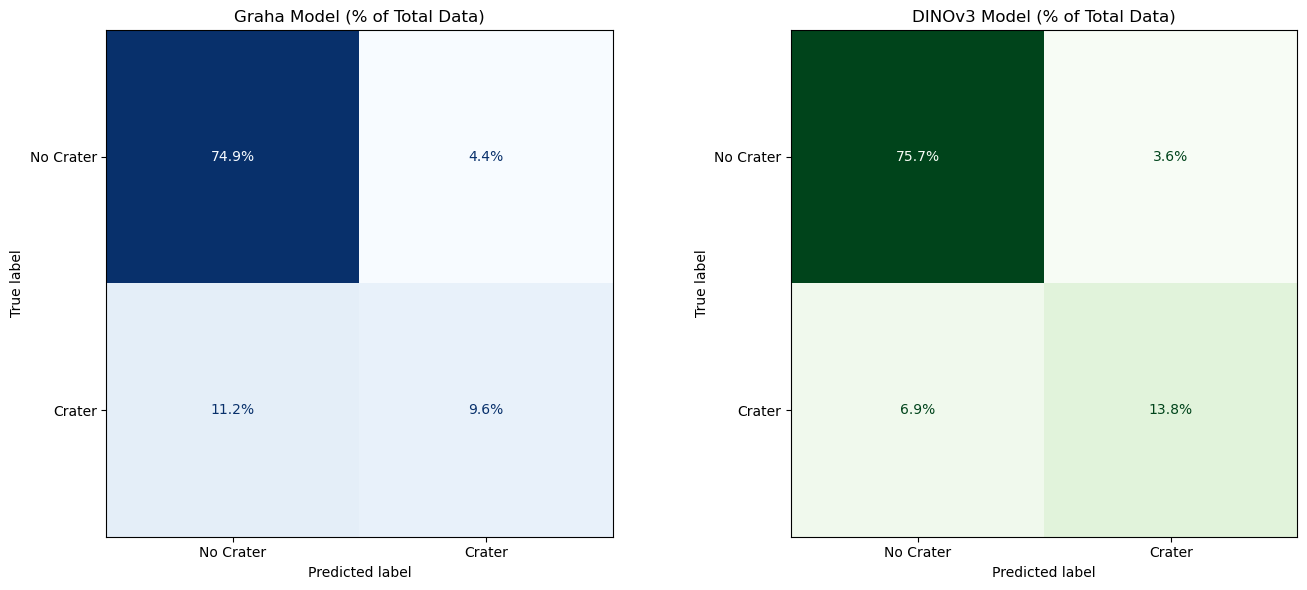

In [6]:
# Calculate Global Metrics for Graha
g_acc = accuracy_score(all_labels, all_graha_preds)
g_prec = precision_score(all_labels, all_graha_preds, average='binary', zero_division=0)
g_rec = recall_score(all_labels, all_graha_preds, average='binary', zero_division=0)
g_iou = jaccard_score(all_labels, all_graha_preds, average='binary', zero_division=0)

# Calculate Global Metrics for DINOv3
d_acc = accuracy_score(all_labels, all_dino_preds)
d_prec = precision_score(all_labels, all_dino_preds, average='binary', zero_division=0)
d_rec = recall_score(all_labels, all_dino_preds, average='binary', zero_division=0)
d_iou = jaccard_score(all_labels, all_dino_preds, average='binary', zero_division=0)

# Print the overall metrics
print("="*50)
print("OVERALL GLOBAL METRICS (All Pixels)")
print("="*50)
print(f"Graha  -> Accuracy (TP+FN): {g_acc:.4f} | Precision (TP/(TP+FP)): {g_prec:.4f} | Recall (TP/(TP+FN)): {g_rec:.4f} | IoU: {g_iou:.4f}")
print(f"DINOv3 -> Accuracy (TP+FN): {d_acc:.4f} | Precision (TP/(TP+FP)): {d_prec:.4f} | Recall (TP/(TP+FN)): {d_rec:.4f} | IoU: {d_iou:.4f}")
print("="*50)

# Define custom class labels (0 = no crater, 1 = crater)
class_names = ["No Crater", "Crater"]

# Plot the Confusion Matrices as percentages of the total data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graha Confusion Matrix (Normalized)
cm_graha = confusion_matrix(all_labels, all_graha_preds, normalize='all')
disp_graha = ConfusionMatrixDisplay(confusion_matrix=cm_graha, display_labels=class_names)
# values_format='.1%' displays percentages with 1 decimal place
disp_graha.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='.1%')
axes[0].set_title("Graha Model (% of Total Data)")

# DINOv3 Confusion Matrix (Normalized)
cm_dino = confusion_matrix(all_labels, all_dino_preds, normalize='all')
disp_dino = ConfusionMatrixDisplay(confusion_matrix=cm_dino, display_labels=class_names)
disp_dino.plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='.1%')
axes[1].set_title("DINOv3 Model (% of Total Data)")

plt.tight_layout()
plt.show()

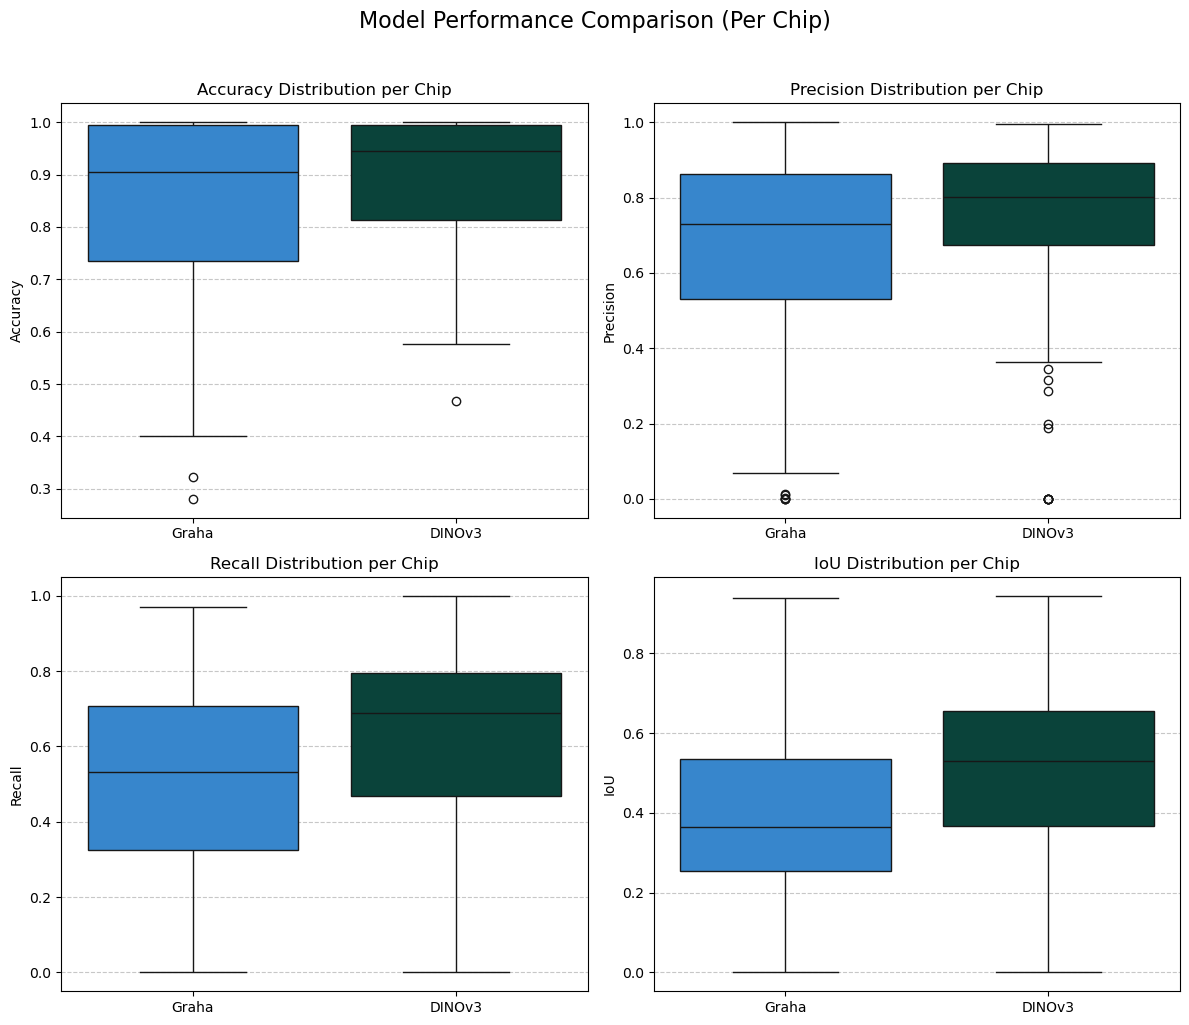

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

metrics_to_plot = ["Accuracy", "Precision", "Recall", "IoU"]

for i, metric in enumerate(metrics_to_plot):
    sns.boxplot(
        data=df_metrics, 
        x="Model", 
        y=metric, 
        hue="Model",         # <--- Added to fix the warning
        legend=False,        # <--- Added to fix the warning
        ax=axes[i], 
        palette={"Graha": "#1E88E5", "DINOv3": "#004D40"} 
    )
    axes[i].set_title(f"{metric} Distribution per Chip")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric)
    axes[i].yaxis.grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Model Performance Comparison (Per Chip)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, jaccard_score

# Set base directories
BASE_DIR = "/explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/sem_ckpt_sweep_date_2026_07_20-time_09_28_28"
GRAHA_DIR = os.path.join(BASE_DIR, "graha_model")
DINO_DIR = os.path.join(BASE_DIR, "toy_model")

# Standard Colors
COLOR_GRAHA = "#1E88E5"
COLOR_DINO = "#004D40"

# Find all epoch folders and sort them numerically
epoch_folders = sorted([d for d in os.listdir(GRAHA_DIR) if d.startswith("epoch_")])

# Dictionaries to store the metrics over time
graha_history = {"Epoch": [], "Accuracy": [], "Precision": [], "Recall": [], "IoU": []}
dino_history = {"Epoch": [], "Accuracy": [], "Precision": [], "Recall": [], "IoU": []}

print(f"Starting metric calculations across {len(epoch_folders)} epochs. This may take a few minutes...")

for epoch in epoch_folders:
    epoch_num = int(epoch.split('_')[1]) # Extract the number (e.g., 0 from 'epoch_000')
    
    # Paths for this specific epoch
    graha_epoch_dir = os.path.join(GRAHA_DIR, epoch)
    dino_epoch_dir = os.path.join(DINO_DIR, epoch)
    
    # We assume patches are the same across models, so we get the list from Graha
    if not os.path.exists(graha_epoch_dir): continue
    patch_dirs = [d for d in os.listdir(graha_epoch_dir) if os.path.isdir(os.path.join(graha_epoch_dir, d))]
    
    # Temporary lists to hold flattened arrays for this single epoch
    g_lbls, g_preds = [], []
    d_lbls, d_preds = [], []
    
    for chip in patch_dirs:
        # Graha Files
        g_lbl_path = os.path.join(graha_epoch_dir, chip, f"{chip}_label.npy")
        g_prd_path = os.path.join(graha_epoch_dir, chip, f"{chip}_pred.npy")
        if os.path.exists(g_lbl_path) and os.path.exists(g_prd_path):
            g_lbls.append(np.load(g_lbl_path).flatten())
            g_preds.append(np.load(g_prd_path).flatten())
            
        # DINOv3 Files
        d_lbl_path = os.path.join(dino_epoch_dir, chip, f"{chip}_label.npy")
        d_prd_path = os.path.join(dino_epoch_dir, chip, f"{chip}_pred.npy")
        if os.path.exists(d_lbl_path) and os.path.exists(d_prd_path):
            d_lbls.append(np.load(d_lbl_path).flatten())
            d_preds.append(np.load(d_prd_path).flatten())
            
    # Calculate Graha metrics for this epoch
    if len(g_lbls) > 0:
        y_true_g = np.concatenate(g_lbls)
        y_pred_g = np.concatenate(g_preds)
        
        graha_history["Epoch"].append(epoch_num)
        graha_history["Accuracy"].append(accuracy_score(y_true_g, y_pred_g))
        graha_history["Precision"].append(precision_score(y_true_g, y_pred_g, average='binary', zero_division=0))
        graha_history["Recall"].append(recall_score(y_true_g, y_pred_g, average='binary', zero_division=0))
        graha_history["IoU"].append(jaccard_score(y_true_g, y_pred_g, average='binary', zero_division=0))
        
    # Calculate DINOv3 metrics for this epoch
    if len(d_lbls) > 0:
        y_true_d = np.concatenate(d_lbls)
        y_pred_d = np.concatenate(d_preds)
        
        dino_history["Epoch"].append(epoch_num)
        dino_history["Accuracy"].append(accuracy_score(y_true_d, y_pred_d))
        dino_history["Precision"].append(precision_score(y_true_d, y_pred_d, average='binary', zero_division=0))
        dino_history["Recall"].append(recall_score(y_true_d, y_pred_d, average='binary', zero_division=0))
        dino_history["IoU"].append(jaccard_score(y_true_d, y_pred_d, average='binary', zero_division=0))
        
    # Print progress every 10 epochs
    if epoch_num % 10 == 0:
        print(f"Processed up to {epoch}...")

print("Calculations complete! Saving metrics to CSV...")

# Convert to DataFrames and save them to your base directory
df_graha = pd.DataFrame(graha_history)
df_dino = pd.DataFrame(dino_history)


Starting metric calculations across 100 epochs. This may take a few minutes...
Processed up to epoch_000...
Processed up to epoch_010...
Processed up to epoch_020...
Processed up to epoch_030...
Processed up to epoch_040...
Processed up to epoch_050...
Processed up to epoch_060...
Processed up to epoch_070...
Processed up to epoch_080...
Processed up to epoch_090...
Calculations complete! Saving metrics to CSV...


PermissionError: [Errno 13] Permission denied: '/explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/sem_ckpt_sweep_date_2026_07_20-time_09_28_28/graha_calculated_metrics_history.csv'

Saving metrics to your temp folder...
Successfully saved to /explore/nobackup/people/mfrost2/temp/!


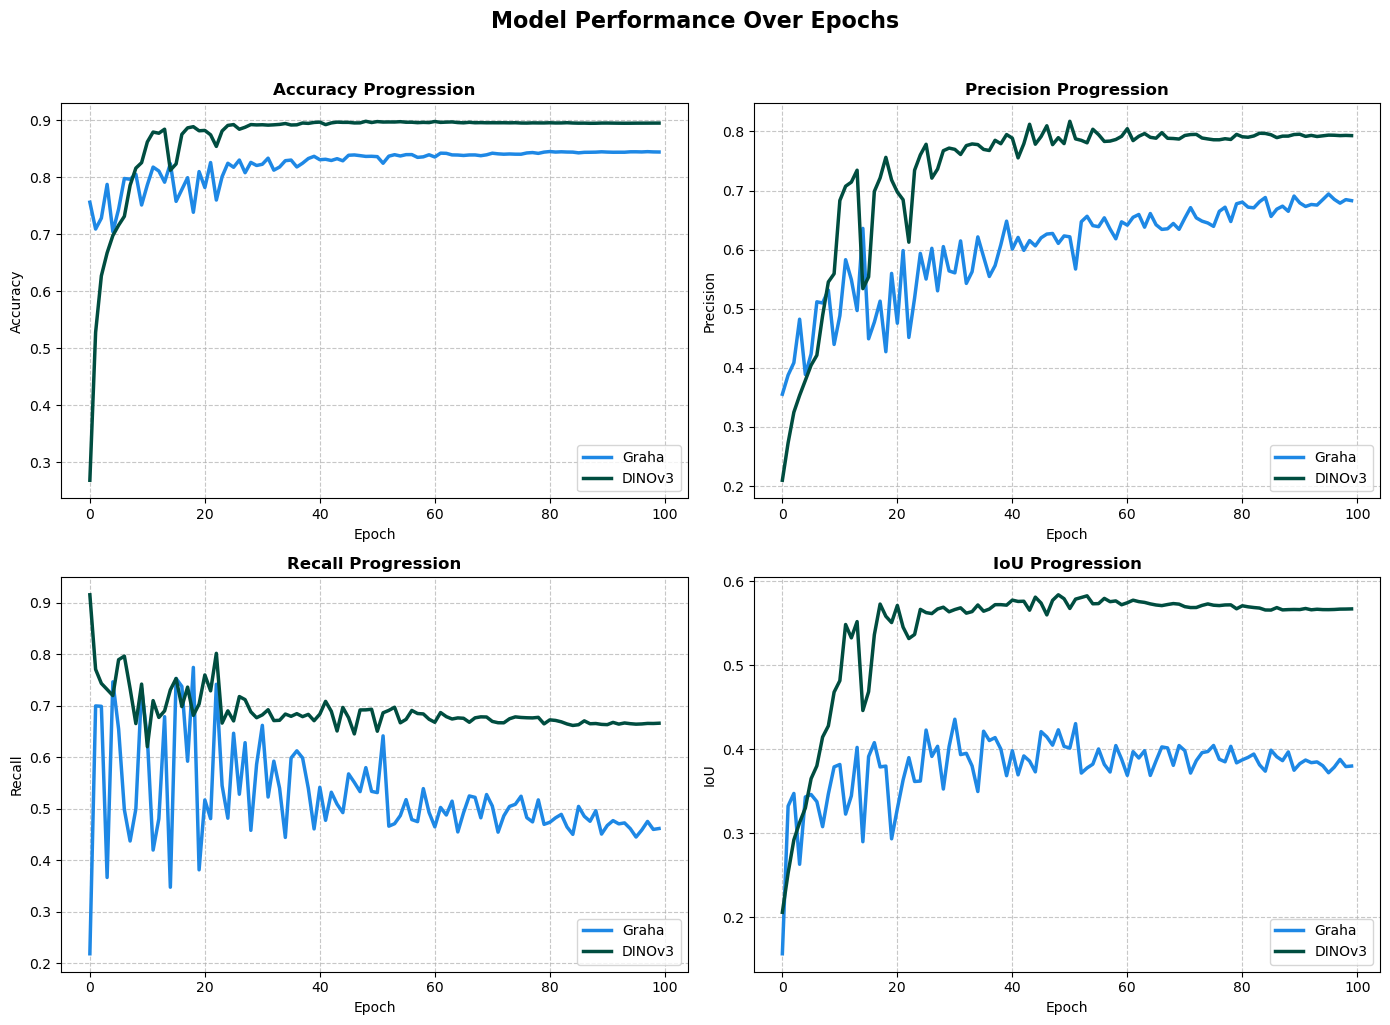

In [10]:
import os

# Define your personal save directory
SAVE_DIR = "/explore/nobackup/people/mfrost2/temp/"

# Create the directory if it doesn't exist yet
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving metrics to your temp folder...")

# df_graha and df_dino are already in your notebook's memory from the last run!
df_graha.to_csv(os.path.join(SAVE_DIR, "graha_calculated_metrics_history.csv"), index=False)
df_dino.to_csv(os.path.join(SAVE_DIR, "dinov3_calculated_metrics_history.csv"), index=False)

print(f"Successfully saved to {SAVE_DIR}!")

# --- PLOTTING ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = ["Accuracy", "Precision", "Recall", "IoU"]

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    # Plot Graha Line
    if metric in df_graha.columns and len(df_graha) > 0:
        ax.plot(df_graha["Epoch"], df_graha[metric], label="Graha", color=COLOR_GRAHA, linewidth=2.5)
        
    # Plot DINOv3 Line
    if metric in df_dino.columns and len(df_dino) > 0:
        ax.plot(df_dino["Epoch"], df_dino[metric], label="DINOv3", color=COLOR_DINO, linewidth=2.5)
        
    ax.set_title(f"{metric} Progression", fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='lower right')

plt.suptitle("Model Performance Over Epochs", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

=== Graha Metrics for M1098029461CE_r2850_c450 ===
metrics.txt not found.

metrics.npy not found.


=== DINOv3 Metrics for M1098029461CE_r2850_c450 ===
metrics.txt not found.

metrics.npy not found.


